# Modelos de Lenguaje con N-Gramas

**Objetivo:** Comprender e implementar modelos de lenguaje estadísticos basados en n-gramas, desde la intuición básica hasta el entrenamiento de un modelo funcional con NLTK.

**Datos:** Versión estenográfica de una sesión ordinaria del Pleno de la Comisión Federal de Competencia Económica (COFECE), 5 de enero de 2023.

## 1. Introducción

### 1.1 ¿Qué es un modelo de lenguaje?

Un **modelo de lenguaje** aprende a asignar probabilidades a secuencias de palabras. Dada una secuencia de palabras previas, el modelo estima cuál es la siguiente palabra más probable. Esta capacidad es fundamental para:

- Autocompletado y predicción de texto
- Reconocimiento de voz y OCR
- Corrección ortográfica
- Traducción automática

Existen dos grandes familias:

- **Modelos estadísticos:** N-gramas, modelos ocultos de Markov (HMM). Usan conteos y reglas probabilísticas directas.
- **Modelos neuronales:** RNNs, Transformers (GPT, BERT). Aprenden representaciones densas del lenguaje.

En este notebook nos enfocamos en los **modelos estadísticos basados en n-gramas**, que son el punto de partida conceptual para entender modelos más complejos.

### 1.2 La idea central: predecir la siguiente palabra

Lo que buscamos es estimar la probabilidad condicional:

$$P(w_n \mid w_1, w_2, \ldots, w_{n-1})$$

Es decir: *¿qué tan probable es la palabra $w_n$ dado que las palabras anteriores fueron $w_1, \ldots, w_{n-1}$?*

El problema es que estimar esta probabilidad para secuencias largas requiere cantidades enormes de datos. La solución práctica es la **aproximación de Markov**: asumir que la probabilidad de la siguiente palabra depende solo de las últimas $n-1$ palabras.

### 1.3 ¿Qué es un n-grama?

Un **n-grama** es una subsecuencia contigua de $n$ elementos extraída de un texto:

| n | Nombre | Ejemplo ("el gato come pescado") |
|---|--------|----------------------------------|
| 1 | Unigrama | "el", "gato", "come", "pescado" |
| 2 | Bigrama | "el gato", "gato come", "come pescado" |
| 3 | Trigrama | "el gato come", "gato come pescado" |

### 1.4 Estimación por máxima verosimilitud (MLE)

Para un modelo de **bigramas**, la probabilidad de una palabra $w_n$ dada la anterior $w_{n-1}$ se estima como:

$$P(w_n \mid w_{n-1}) = \frac{C(w_{n-1}, w_n)}{C(w_{n-1})}$$

Donde $C(\cdot)$ es el conteo de ocurrencias en el corpus de entrenamiento. Es decir, contamos cuántas veces aparece el bigrama dividido entre cuántas veces aparece la primera palabra.

**Ejemplo:** Si en el corpus "el gato" aparece 5 veces y "el" aparece 100 veces, entonces $P(\text{gato} \mid \text{el}) = 5/100 = 0.05$.

### 1.5 El problema de las probabilidades cero y el suavizado

¿Qué pasa si un bigrama nunca apareció en los datos de entrenamiento? Su conteo es 0, lo que hace $P = 0$. Esto es problemático porque una sola probabilidad cero anula la probabilidad de toda una oración.

**Suavizado de Laplace (add-1):** Se suma 1 a todos los conteos antes de calcular probabilidades:

$$P_{\text{Laplace}}(w_n \mid w_{n-1}) = \frac{C(w_{n-1}, w_n) + 1}{C(w_{n-1}) + V}$$

Donde $V$ es el tamaño del vocabulario. Esto garantiza que ningún n-grama tenga probabilidad cero.

## 2. N-gramas desde cero (implementación manual)

Antes de usar librerías, vamos a entender la mecánica construyendo n-gramas paso a paso.

### 2.1 Slicing de strings en Python

Los n-gramas se apoyan en la operación de *slicing* — extraer subsecuencias de una cadena o lista. Repasemos rápidamente cómo funciona.

In [1]:
# Dependencies
import re
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Slicing básico de strings
texto = "¿Clases en sábado?"

print(f"texto[1:8]   = '{texto[1:8]}'")    # Caracteres 1 al 7
print(f"texto[:3]    = '{texto[:3]}'")      # Primeros 3 caracteres
print(f"texto[3:]    = '{texto[3:]}'")      # Del 3 al final
print(f"texto[:-1]   = '{texto[:-1]}'")     # Todo menos el último

texto[1:8]   = 'Clases '
texto[:3]    = '¿Cl'
texto[3:]    = 'ases en sábado?'
texto[:-1]   = '¿Clases en sábado'


### 2.2 De texto a lista de palabras

La operación `.split()` separa un string por espacios y devuelve una lista de palabras (tokens). Esta lista es la materia prima para construir n-gramas.

In [3]:
# Texto de ejemplo (inicio de "A Tale of Two Cities" de Dickens)
cadena = 'it was the best of times it was the worst of times '
cadena += 'it was the age of wisdom it was the age of foolishness'

palabras = cadena.split()
print(f"Total de palabras: {len(palabras)}")
print(f"Palabras: {palabras}")

Total de palabras: 24
Palabras: ['it', 'was', 'the', 'best', 'of', 'times', 'it', 'was', 'the', 'worst', 'of', 'times', 'it', 'was', 'the', 'age', 'of', 'wisdom', 'it', 'was', 'the', 'age', 'of', 'foolishness']


### 2.3 Construir n-gramas manualmente

La idea es deslizar una ventana de tamaño $n$ sobre la lista de palabras. Hay dos formas equivalentes de implementarlo: con una *list comprehension* (compacta) o con un *for loop* (más explícita).

In [4]:
# Versión con list comprehension
def obtener_ngramas(lista_palabras, n):
    """Genera todos los n-gramas de una lista de palabras."""
    return [lista_palabras[i : i + n] for i in range(len(lista_palabras) - (n - 1))]

# Versión equivalente con for loop (más explícita)
def obtener_ngramas_loop(lista_palabras, n):
    """Misma función, versión expandida para claridad."""
    ngramas = []
    for i in range(len(lista_palabras) - (n - 1)):
        ngramas.append(lista_palabras[i : i + n])
    return ngramas

In [5]:
# Bigramas
bigramas = obtener_ngramas(palabras, 2)

print(f"Número de bigramas: {len(bigramas)}")
print(f"Primeros 5: {bigramas[:5]}")
print(f"Últimos 5:  {bigramas[-5:]}")

Número de bigramas: 23
Primeros 5: [['it', 'was'], ['was', 'the'], ['the', 'best'], ['best', 'of'], ['of', 'times']]
Últimos 5:  [['it', 'was'], ['was', 'the'], ['the', 'age'], ['age', 'of'], ['of', 'foolishness']]


In [6]:
# Trigramas
trigramas = obtener_ngramas(palabras, 3)

print(f"Número de trigramas: {len(trigramas)}")
print(f"Primeros 5: {trigramas[:5]}")

Número de trigramas: 22
Primeros 5: [['it', 'was', 'the'], ['was', 'the', 'best'], ['the', 'best', 'of'], ['best', 'of', 'times'], ['of', 'times', 'it']]


### 2.4 Frecuencias y probabilidades de n-gramas

A partir de los n-gramas podemos calcular:
1. **Frecuencias:** ¿cuántas veces aparece cada n-grama?
2. **Probabilidades:** frecuencia relativa de cada n-grama (MLE).

Estas probabilidades son la base del modelo de lenguaje.

In [7]:
# Frecuencia de unigramas (palabras individuales)
freq_uni = pd.Series(palabras).value_counts()
print("=== Frecuencias de unigramas (top 10) ===")
print(freq_uni.head(10))
print(f"\nVocabulario: {len(freq_uni)} palabras únicas")

=== Frecuencias de unigramas (top 10) ===
it             4
was            4
the            4
of             4
times          2
age            2
best           1
worst          1
wisdom         1
foolishness    1
Name: count, dtype: int64

Vocabulario: 10 palabras únicas


In [8]:
# Frecuencia de bigramas
# Convertimos cada bigrama (lista) a tupla para poder contar
freq_bi = pd.Series([tuple(b) for b in bigramas]).value_counts()

print("=== Frecuencias de bigramas (top 10) ===")
print(freq_bi.head(10))

=== Frecuencias de bigramas (top 10) ===
(it, was)       4
(was, the)      4
(of, times)     2
(the, age)      2
(times, it)     2
(age, of)       2
(the, best)     1
(best, of)      1
(the, worst)    1
(worst, of)     1
Name: count, dtype: int64


In [9]:
# Probabilidades de bigramas (MLE)
prob_bi = freq_bi / freq_bi.sum()

print("=== Probabilidades de bigramas (top 10) ===")
print(prob_bi.head(10))
print(f"\nSuma total de probabilidades: {prob_bi.sum():.4f}")

=== Probabilidades de bigramas (top 10) ===
(it, was)       0.173913
(was, the)      0.173913
(of, times)     0.086957
(the, age)      0.086957
(times, it)     0.086957
(age, of)       0.086957
(the, best)     0.043478
(best, of)      0.043478
(the, worst)    0.043478
(worst, of)     0.043478
Name: count, dtype: float64

Suma total de probabilidades: 1.0000


### 2.5 Probabilidad condicional: predicción de la siguiente palabra

Con las frecuencias podemos calcular $P(w_2 \mid w_1)$. Por ejemplo: dada la palabra "it", ¿qué palabra sigue con mayor probabilidad?

In [10]:
# P(w2 | w1 = "of") — ¿qué sigue después de "of"?
palabra_contexto = "of"

# Filtrar bigramas que empiezan con "of"
bigramas_contexto = [(b[0], b[1]) for b in bigramas if b[0] == palabra_contexto]
freq_contexto = pd.Series([b[1] for b in bigramas_contexto]).value_counts()

# Probabilidad condicional = conteo(bigrama) / conteo(palabra contexto)
prob_condicional = freq_contexto / freq_contexto.sum()

print(f'P(w | "{palabra_contexto}") =')
print(prob_condicional)
print(f'\nInterpretación: después de "{palabra_contexto}", ')
print(f'la palabra más probable es "{prob_condicional.index[0]}" con P={prob_condicional.iloc[0]:.2%}')

P(w | "of") =
times          0.50
wisdom         0.25
foolishness    0.25
Name: count, dtype: float64

Interpretación: después de "of", 
la palabra más probable es "times" con P=50.00%


In [11]:
# Hagamos lo mismo para "it"
palabra_contexto = "it"
bigramas_ctx = [(b[0], b[1]) for b in bigramas if b[0] == palabra_contexto]
prob_ctx = pd.Series([b[1] for b in bigramas_ctx]).value_counts(normalize=True)

print(f'P(w | "{palabra_contexto}") =')
print(prob_ctx)

P(w | "it") =
was    1.0
Name: proportion, dtype: float64


## 3. Entrenamiento de un modelo N-grama con NLTK

Ahora que entendemos la mecánica, usamos la librería **NLTK** para entrenar un modelo de lenguaje completo sobre un texto real: la versión estenográfica de una sesión del Pleno de la COFECE.

### 3.1 ¿Qué hace NLTK por nosotros?

NLTK provee herramientas que automatizan pasos que hicimos manualmente:

| Paso | Manual | NLTK |
|------|--------|------|
| Tokenizar | `.split()` | `word_tokenize()` (más sofisticado: maneja puntuación) |
| Construir n-gramas | nuestra función `obtener_ngramas` | `ngrams()`, `bigrams()`, `everygrams()` |
| Padding | no lo hicimos | `pad_both_ends()` — agrega tokens `<s>` y `</s>` para marcar inicio/fin |
| Pipeline completo | varios pasos | `padded_everygram_pipeline()` — todo en una llamada |
| Modelo MLE | cálculo manual | `MLE()` — ajusta y permite consultar probabilidades y generar texto |

In [12]:
#
import nltk
nltk.download('punkt_tab', quiet=True)

from nltk.util import pad_sequence, bigrams, ngrams, everygrams
from nltk.lm.preprocessing import pad_both_ends, flatten, padded_everygram_pipeline
from nltk import word_tokenize, sent_tokenize
from nltk.lm import MLE

### 3.2 Carga y limpieza del texto

El archivo `VEP_20230105_1.txt` contiene la versión estenográfica de la primera sesión ordinaria del Pleno de la COFECE del 5 de enero de 2023. Es un texto legal/institucional con vocabulario especializado.

In [14]:
# Leer el archivo
with open('VEP_20230105_1.txt', 'r') as f:
    contenido = f.read()

# Convertir a minúsculas (normalización básica)
contenido = contenido.lower()

# Estadísticas básicas del texto
palabras_raw = contenido.split()
print(f"Caracteres totales: {len(contenido):,}")
print(f"Palabras (split): {len(palabras_raw):,}")
print(f"Palabras únicas: {len(set(palabras_raw)):,}")
print(f"\nPrimeras 100 palabras:")
print(' '.join(palabras_raw[:100]))

Caracteres totales: 23,863
Palabras (split): 3,705
Palabras únicas: 1,033

Primeras 100 palabras:
versión pública unidad administrativa que clasifica: secretaría técnica número de acta y fecha en la que se aprobó por el comité: cot-004-2023 – 25 de enero de 2023 descripción del documento: versión pública de la versión estenográfica de la primera sesión ordinaria del pleno de la comisión federal de competencia económica celebrada el cinco de enero de dos mil veintitrés. tipo de información clasificada y fundamento legal: información confidencial la información testada e identificada con la letra b es confidencial en términos de los artículos 113, fracción iii, de la ley federal de transparencia y acceso a la información públi


### 3.3 Tokenización y padding

Antes de entrenar el modelo necesitamos dos pasos:

1. **Tokenización** (`word_tokenize`): divide el texto en tokens, separando la puntuación de las palabras (a diferencia de `.split()`).
2. **Padding** (`pad_both_ends`): agrega tokens especiales `<s>` al inicio y `</s>` al final. Esto permite que el modelo aprenda qué palabras suelen iniciar y terminar oraciones.

El parámetro `n` en el padding indica el orden del modelo: para un modelo de n-gramas de orden $n$, se agregan $n-1$ tokens de inicio.

In [15]:
# Tokenizar y agregar padding para un modelo de 5-gramas
# pad_both_ends agrega (n-1) tokens <s> al inicio y 1 token </s> al final

paddedLine = [list(pad_both_ends(word_tokenize(contenido), n=2))]

print(f"Tokens totales (con padding): {len(paddedLine[0]):,}")
print(f"\nPrimeros 15 tokens:  {paddedLine[0][:15]}")
print(f"Últimos 10 tokens:   {paddedLine[0][-10:]}")

Tokens totales (con padding): 4,182

Primeros 15 tokens:  ['<s>', 'versión', 'pública', 'unidad', 'administrativa', 'que', 'clasifica', ':', 'secretaría', 'técnica', 'número', 'de', 'acta', 'y', 'fecha']
Últimos 10 tokens:   ['.', 'fgsa', ':', 'muchas', 'g', 'racias', ',', 'comisionados', '.', '</s>']


### 3.4 Pipeline de preparación y entrenamiento

`padded_everygram_pipeline` combina tokenización, padding y generación de todos los n-gramas (de orden 1 hasta $n$) en una sola llamada. Devuelve:

- **`train`**: un generador de *everygrams* (todos los n-gramas de 1 hasta $n$) — es lo que alimenta al modelo.
- **`vocab`**: un generador con todas las palabras del corpus — define el vocabulario del modelo.

Luego `MLE(n)` crea un modelo de **Máxima Verosimilitud** de orden $n$ y `.fit()` lo entrena.

In [16]:
# Preparar datos para un modelo de 5-gramas
N_ORDER = 5

train, vocab = padded_everygram_pipeline(N_ORDER, paddedLine)

# Entrenar el modelo MLE
lm = MLE(N_ORDER)
lm.fit(train, vocab)

print(f"Modelo entrenado: {N_ORDER}-gramas")
print(f"Tamaño del vocabulario: {len(lm.vocab):,} tokens")

Modelo entrenado: 5-gramas
Tamaño del vocabulario: 913 tokens


### 3.5 Exploración del modelo entrenado

Ahora podemos consultar el modelo de varias formas:

- **`lm.counts[palabra]`**: ¿cuántas veces apareció una palabra?
- **`lm.score(palabra)`**: probabilidad P(palabra) — probabilidad marginal del unigrama.
- **`lm.score(palabra, contexto)`**: probabilidad condicional P(palabra | contexto).
- **`lm.vocab.lookup(palabra)`**: verifica si la palabra está en el vocabulario (devuelve `<UNK>` si no).

In [17]:
# Conteos de palabras individuales
palabras_ejemplo = ['ley', 'comisionado', 'pleno', 'competencia', 'mercado']

print("=== Conteos de unigramas ===")
for p in palabras_ejemplo:
    print(f"  '{p}': {lm.counts[p]} ocurrencias")

=== Conteos de unigramas ===
  'ley': 14 ocurrencias
  'comisionado': 4 ocurrencias
  'pleno': 23 ocurrencias
  'competencia': 26 ocurrencias
  'mercado': 0 ocurrencias


In [18]:
# Probabilidades marginales (unigramas)
print("=== Probabilidades P(palabra) ===")
for p in palabras_ejemplo:
    print(f"  P('{p}') = {lm.score(p):.6f}")

# Verificar que una palabra fuera de vocabulario devuelve <UNK>
print(f"\nlm.vocab.lookup('blockchain') = '{lm.vocab.lookup('blockchain')}'")
print(f"lm.vocab.lookup('ley')        = '{lm.vocab.lookup('ley')}'")

=== Probabilidades P(palabra) ===
  P('ley') = 0.003341
  P('comisionado') = 0.000955
  P('pleno') = 0.005489
  P('competencia') = 0.006205
  P('mercado') = 0.000000

lm.vocab.lookup('blockchain') = '<UNK>'
lm.vocab.lookup('ley')        = 'ley'


In [19]:
# Probabilidades condicionales: P(palabra | contexto)
# ¿Qué tan probable es "económica" después de "competencia"?
print("=== Probabilidades condicionales ===")
print(f"  P('económica' | 'competencia') = {lm.score('económica', ['competencia']):.4f}")
print(f"  P('ley'       | 'la')          = {lm.score('ley', ['la']):.4f}")
print(f"  P('federal'   | 'comisión')    = {lm.score('federal', ['comisión']):.4f}")
print(f"  P('pleno'     | 'del')         = {lm.score('pleno', ['del']):.4f}")

=== Probabilidades condicionales ===
  P('económica' | 'competencia') = 0.8846
  P('ley'       | 'la')          = 0.0795
  P('federal'   | 'comisión')    = 0.5000
  P('pleno'     | 'del')         = 0.1746


### 3.6 Generación de texto

La función `lm.generate(n)` genera $n$ tokens muestreando secuencialmente del modelo: elige la siguiente palabra según las probabilidades condicionadas en el contexto generado hasta el momento.

- **`random_seed`**: fija la semilla para reproducibilidad.
- **`text_seed`**: palabras iniciales que sirven de contexto para la generación.

In [20]:
# Generar 1 palabra (sin contexto)
print("1 palabra:", lm.generate(1, random_seed=3))
print()

# Generar 5 palabras
print("5 palabras:", lm.generate(5, random_seed=3))
print()

# Generar 20 palabras
texto_20 = lm.generate(20, random_seed=42)
print("20 palabras:", ' '.join(texto_20))

1 palabra: asimismo

5 palabras: ['asimismo', ',', 'deberán', 'publicar', 'en']

20 palabras: la autoridad investig adora para la toma de decisiones del titular de la autoridad investig adora para la toma de


In [21]:
# Generación con semilla de texto (contexto inicial)
# Le damos una palabra inicial y el modelo continúa desde ahí

semillas = [['comisión'], ['ley'], ['el', 'pleno']]

for seed in semillas:
    texto_gen = lm.generate(15, text_seed=seed, random_seed=42)
    print(f"Semilla: {seed}")
    print(f"  → {' '.join(seed)} {' '.join(texto_gen)}")
    print()

Semilla: ['comisión']
  → comisión federal de competencia económica ] para emitir lineamientos con posterioridad a la consulta pública a

Semilla: ['ley']
  → ley federal de competencia económica ] para emitir lineamientos con posterioridad a la consulta pública a

Semilla: ['el', 'pleno']
  → el pleno de esta comisión emitió un acuerdo por medio del cual , por falta de quorum



## 4. Análisis del modelo

### 4.1 Distribución de frecuencias

Examinemos la distribución de frecuencias del vocabulario — una característica universal de los textos conocida como la **Ley de Zipf**: pocas palabras son muy frecuentes y la gran mayoría son raras.

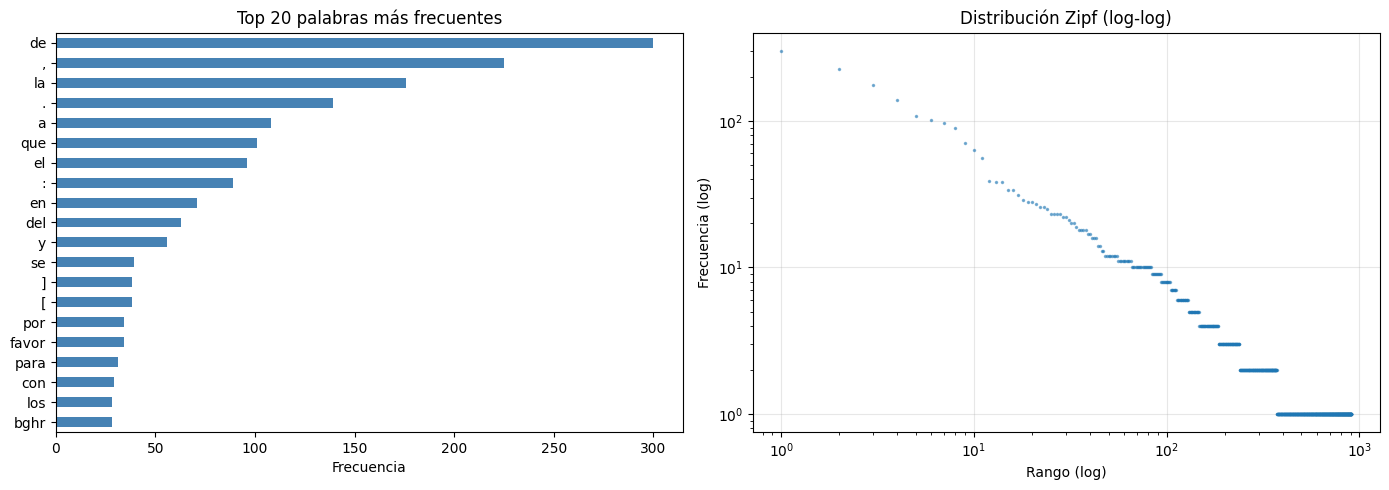

Vocabulario total: 910 tokens únicos
Tokens que aparecen 1 sola vez (hapax legomena): 538 (59%)


In [22]:
# Distribución de frecuencias del vocabulario
import matplotlib.pyplot as plt

# Obtener conteos de todos los unigramas
tokens_all = paddedLine[0]
freq_all = pd.Series(tokens_all).value_counts()

# Excluir tokens especiales de padding
freq_all = freq_all[~freq_all.index.isin(['<s>', '</s>'])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Top 20 palabras más frecuentes
freq_all.head(20).plot.barh(ax=ax1, color='steelblue')
ax1.set_xlabel('Frecuencia')
ax1.set_title('Top 20 palabras más frecuentes')
ax1.invert_yaxis()

# Distribución log-log (Ley de Zipf)
ranks = np.arange(1, len(freq_all) + 1)
ax2.loglog(ranks, freq_all.values, '.', markersize=3, alpha=0.5)
ax2.set_xlabel('Rango (log)')
ax2.set_ylabel('Frecuencia (log)')
ax2.set_title('Distribución Zipf (log-log)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Vocabulario total: {len(freq_all)} tokens únicos")
print(f"Tokens que aparecen 1 sola vez (hapax legomena): {(freq_all == 1).sum()} ({(freq_all == 1).mean():.0%})")

### 4.2 Bigramas más frecuentes

Los bigramas más frecuentes revelan las frases y expresiones recurrentes del texto. En un texto legal/institucional como este, esperamos ver fórmulas legales y nombres de instituciones.

In [23]:
# Top bigramas
tokens_clean = [t for t in tokens_all if t not in ['<s>', '</s>']]
bigs = list(ngrams(tokens_clean, 2))
freq_bigs = pd.Series([' '.join(b) for b in bigs]).value_counts()

print("=== Top 20 bigramas ===")
print(freq_bigs.head(20).to_string())

=== Top 20 bigramas ===
de la                    60
, a                      34
a favor                  31
bghr :                   27
favor .                  27
de competencia           25
. bghr                   23
federal de               23
competencia económica    23
a la                     21
, en                     20
pleno de                 19
en el                    19
que se                   18
dos mil                  18
de dos                   17
en la                    17
muchas gracias           16
de enero                 16
gracias ,                16


In [24]:
# Top trigramas
trigs = list(ngrams(tokens_clean, 3))
freq_trigs = pd.Series([' '.join(t) for t in trigs]).value_counts()

print("=== Top 20 trigramas ===")
print(freq_trigs.head(20).to_string())

=== Top 20 trigramas ===
, a favor                    29
a favor .                    27
de competencia económica     23
. bghr :                     23
federal de competencia       22
de dos mil                   17
de enero de                  15
. fgsa :                     15
de la ley                    13
de la comisión               13
andrea marván saltiel        12
gisela hernández ramírez     11
competencia económica ,      11
brenda gisela hernández      11
eduardo mendoza contreras    11
josé eduardo mendoza         11
: muchas gracias             11
comisionada [ andrea         10
muchas gracias ,             10
diciembre de dos             10


### 4.3 Evaluación: perplejidad

La **perplejidad** (*perplexity*) es la métrica estándar para evaluar modelos de lenguaje. Mide qué tan "sorprendido" está el modelo ante un texto: valores más bajos indican un mejor modelo.

$$\text{Perplexity} = 2^{-\frac{1}{N} \sum_{i=1}^{N} \log_2 P(w_i \mid \text{contexto})}$$

⚠️ **Nota:** Con MLE sin suavizado, la perplejidad será infinita si el texto contiene algún n-grama no visto en entrenamiento. En un escenario real se usaría suavizado (Laplace, Kneser-Ney, etc.) o se evaluaría solo sobre el conjunto de entrenamiento.

In [25]:
# Perplejidad sobre una fracción del propio texto de entrenamiento
# (en un escenario real, se evaluaría sobre un conjunto de test separado)

from nltk.util import everygrams as eg

test_tokens = tokens_clean[:200]  # primeros 200 tokens como muestra

# Calcular perplejidad del modelo sobre esta muestra
try:
    ppl = lm.perplexity(test_tokens)
    print(f"Perplejidad sobre los primeros 200 tokens: {ppl:.2f}")
except Exception as e:
    print(f"Error al calcular perplejidad: {e}")
    print("Esto suele ocurrir cuando hay tokens OOV con probabilidad 0 (MLE sin suavizado).")
    print("En producción se usaría un modelo con suavizado (Laplace, Kneser-Ney, etc.)")

Perplejidad sobre los primeros 200 tokens: inf


### 4.4 Efecto del orden n

¿Qué pasa al variar el orden del modelo (bigramas vs trigramas vs 5-gramas)? Modelos de mayor orden capturan más contexto pero necesitan más datos para estimar bien las probabilidades.

In [26]:
# Comparar generación de texto con diferentes órdenes de n-gramas
for n in [2, 3, 5]:
    train_n, vocab_n = padded_everygram_pipeline(n, paddedLine)
    lm_n = MLE(n)
    lm_n.fit(train_n, vocab_n)

    texto_gen = lm_n.generate(20, text_seed=['comisión'], random_seed=42)
    print(f"--- Modelo de {n}-gramas ---")
    print(f"  comisión {' '.join(texto_gen)}")
    print()

--- Modelo de 2-gramas ---
  comisión federal de defensa frente a lo tanto , dicho documento : doy cuenta de la invitación para mayor precisión las

--- Modelo de 3-gramas ---
  comisión federal de competencia económica ] para que dé fe de dicha acción . ams : gracias , comisionado [ alejandro

--- Modelo de 5-gramas ---
  comisión federal de competencia económica ] para emitir lineamientos con posterioridad a la consulta pública a que se sometió el anteproyecto



## 5. Conclusiones

**Resumen de conceptos clave:**

- Un **n-grama** es una subsecuencia contigua de $n$ tokens. Los modelos de n-gramas usan la **propiedad de Markov** para simplificar la predicción: la siguiente palabra depende solo de las últimas $n-1$ palabras.
- La estimación por **máxima verosimilitud (MLE)** calcula probabilidades directamente de los conteos, pero sufre del problema de **probabilidades cero** para n-gramas no vistos.
- El **suavizado** (Laplace, Kneser-Ney) redistribuye masa de probabilidad para manejar n-gramas no vistos.
- Modelos de **mayor orden** capturan más contexto pero son más propensos a datos escasos (*sparsity*).
- La **perplejidad** es la métrica estándar para evaluar modelos de lenguaje.

**Limitaciones de los n-gramas:**
- No capturan dependencias a larga distancia ("El presidente, que fue electo en 2020 y tomó posesión en enero, **dijo**...").
- El vocabulario crece exponencialmente con $n$, haciendo modelos de alto orden imprácticos.
- No generalizan a palabras similares (para el modelo, "perro" y "can" son completamente independientes).

Estas limitaciones motivaron el desarrollo de **modelos neuronales** (Word2Vec, LSTM, Transformers), que abordaremos en notebooks posteriores.

**Posibles extensiones:**
- Implementar suavizado de Laplace y comparar con MLE.
- Usar `nltk.lm.Laplace` o `nltk.lm.KneserNeyInterpolated` para modelos con suavizado.
- Evaluar con perplejidad sobre un conjunto de test separado.
- Aplicar a un corpus más grande para mejorar la calidad de la generación.